# Hypercube Ansatz Visualization in Gemini Physical Squin

This demo recreates the circuit families from `hc_ansatz_visualization.ipynb`, but expresses them directly in the Gemini **physical** dialect used in `bloqade-lanes`.

It mirrors the original notebook's four examples:
- global-parameter hypercube ansatz on an 8-qubit cube
- local-parameter hypercube ansatz on an 8-qubit cube
- reduced-register 6-qubit embedding inside a 3D cube
- 10-qubit `h5` fill-map embedding inside a 4D cube

The source notebook used PennyLane/Cirq for drawing. Here we build equivalent physical `squin` kernels and optionally lower them to the Gemini move dialect.


In [1]:
from __future__ import annotations

from dataclasses import dataclass
from pprint import pprint
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
from bloqade import qubit, squin
from bloqade.lanes.compile import compile_squin_to_move


In [2]:
def hypercube_edges_for_dim(n: int, d: int) -> list[tuple[int, int]]:
    """Return each edge along hypercube dimension ``d`` exactly once."""
    if not (0 <= d < n):
        raise ValueError(f"dimension index {d} out of range for n={n}")
    mask = 1 << d
    return [(i, i ^ mask) for i in range(1 << n) if (i & mask) == 0]


def map_to_hypercube(n: int, m: int) -> dict[int, int]:
    """Phasecraft helper: greedily embed ``m`` labels into an (n+1)-cube."""
    if not (m > 2**n):
        raise ValueError("Require m > 2**n")
    if m > 2 ** (n + 1):
        raise ValueError("Require m <= 2**(n+1)")

    base_size = 2**n
    total_vertices = 2 ** (n + 1)
    mapping = {v: v for v in range(base_size)}
    used_vertices = set(mapping)

    def partner_of(base_vertex: int) -> int:
        return base_vertex + base_size

    for label in range(base_size, m):
        base_candidates = sorted(range(base_size), key=lambda b: (abs(label - b), -b))
        placed = False
        for base_vertex in base_candidates:
            partner = partner_of(base_vertex)
            if partner not in used_vertices:
                mapping[partner] = label
                used_vertices.add(partner)
                placed = True
                break
        if not placed:
            for partner in range(base_size, total_vertices):
                if partner not in used_vertices:
                    mapping[partner] = label
                    used_vertices.add(partner)
                    placed = True
                    break
        if not placed:
            raise RuntimeError("No available vertex to place label")

    return mapping


def count_edges_in_subset(subset_dict: dict[int, int], n: int) -> int:
    vertices = set(subset_dict)
    count = 0
    for v in vertices:
        for d in range(n):
            u = v ^ (1 << d)
            if u in vertices and v < u:
                count += 1
    return count


def make_global_params(n: int, n_layers: int, qub_dicts: Sequence[dict[int, int]] | None = None, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if qub_dicts is None:
        qub_dicts = [{v: v for v in range(1 << n)}] * n_layers
    return rng.uniform(0.0, 2.0 * np.pi, size=3 * n * n_layers)


def make_local_params(n: int, n_layers: int, qub_dicts: Sequence[dict[int, int]] | None = None, seed: int = 0) -> np.ndarray:
    rng = np.random.default_rng(seed)
    if qub_dicts is None:
        qub_dicts = [{v: v for v in range(1 << n)}] * n_layers
    total_edges = sum(count_edges_in_subset(qub_dict, n) for qub_dict in qub_dicts)
    return rng.uniform(0.0, 2.0 * np.pi, size=6 * total_edges)


def emit_single_qubit_block(q, alpha: float, beta: float, gamma: float, *, is_xyx: bool = False) -> None:
    if is_xyx:
        squin.rx(gamma, q)
        squin.ry(beta, q)
        squin.rx(alpha, q)
    else:
        squin.u3(alpha, beta, gamma, q)


@dataclass(frozen=True)
class HCSpec:
    title: str
    single_qub_params: np.ndarray
    n: int
    n_layers: int = 1
    qub_dicts: Sequence[dict[int, int]] | None = None
    local_sq_gates: bool = False
    is_xyx: bool = False


In [3]:
def normalized_qub_dicts(spec: HCSpec) -> list[dict[int, int]]:
    if spec.qub_dicts is None:
        return [{v: v for v in range(1 << spec.n)} for _ in range(spec.n_layers)]
    return [dict(layer_map) for layer_map in spec.qub_dicts]


def expected_param_count(spec: HCSpec) -> int:
    qub_dicts = normalized_qub_dicts(spec)
    if spec.local_sq_gates:
        return 6 * sum(count_edges_in_subset(qub_dict, spec.n) for qub_dict in qub_dicts)
    return 3 * spec.n * spec.n_layers


def kernel_summary(spec: HCSpec) -> dict[str, object]:
    qub_dicts = normalized_qub_dicts(spec)
    active_edges_per_layer = [count_edges_in_subset(qub_dict, spec.n) for qub_dict in qub_dicts]
    total_edges = sum(active_edges_per_layer)
    n_qubits = max(max(layer.values()) for layer in qub_dicts) + 1
    return {
        'n_qubits': n_qubits,
        'n_layers': spec.n_layers,
        'hypercube_dimension': spec.n,
        'local_sq_gates': spec.local_sq_gates,
        'active_edges_per_layer': active_edges_per_layer,
        'total_cz_gates': total_edges,
        'total_single_qubit_blocks': 2 * total_edges,
        'parameter_count': len(spec.single_qub_params),
        'expected_parameter_count': expected_param_count(spec),
    }


def _append_single_qubit_block(lines: list[str], reg_expr: str, alpha: float, beta: float, gamma: float, *, is_xyx: bool):
    if is_xyx:
        lines.append(f"    squin.rx({reg_expr}, {alpha!r})")
        lines.append(f"    squin.ry({reg_expr}, {beta!r})")
        lines.append(f"    squin.rx({reg_expr}, {gamma!r})")
    else:
        lines.append(f"    squin.u3({reg_expr}, {alpha!r}, {beta!r}, {gamma!r})")


def build_hc_kernel(spec: HCSpec):
    import linecache

    qub_dicts = normalized_qub_dicts(spec)
    params = tuple(float(x) for x in np.asarray(spec.single_qub_params, dtype=np.float64))
    expected = expected_param_count(spec)
    if len(params) != expected:
        raise ValueError(f"Expected {expected} parameters, got {len(params)}")

    n_qubits = max(max(layer.values()) for layer in qub_dicts) + 1
    lines = [f"@squin.kernel(typeinfer=True, fold=True)", f"def hc_kernel_{getattr(build_hc_kernel, '_counter', 0)}():", f"    reg = qubit.qalloc({n_qubits})"]
    offset = 0
    for layer in range(spec.n_layers):
        dict_qubs = qub_dicts[layer]
        for d in range(spec.n):
            active_edges = [(i, j) for i, j in hypercube_edges_for_dim(spec.n, d) if i in dict_qubs and j in dict_qubs]
            if not active_edges:
                continue
            if spec.local_sq_gates:
                for i, j in active_edges:
                    alpha = params[offset]
                    beta = params[offset + 1]
                    gamma = params[offset + 2]
                    offset += 3
                    _append_single_qubit_block(lines, f"reg[{dict_qubs[i]}]", alpha, beta, gamma, is_xyx=spec.is_xyx)
                    alpha = params[offset]
                    beta = params[offset + 1]
                    gamma = params[offset + 2]
                    offset += 3
                    _append_single_qubit_block(lines, f"reg[{dict_qubs[j]}]", alpha, beta, gamma, is_xyx=spec.is_xyx)
                    lines.append(f"    squin.cz(reg[{dict_qubs[i]}], reg[{dict_qubs[j]}])")
            else:
                alpha = params[offset]
                beta = params[offset + 1]
                gamma = params[offset + 2]
                offset += 3
                for i, j in active_edges:
                    _append_single_qubit_block(lines, f"reg[{dict_qubs[i]}]", alpha, beta, gamma, is_xyx=spec.is_xyx)
                    _append_single_qubit_block(lines, f"reg[{dict_qubs[j]}]", alpha, beta, gamma, is_xyx=spec.is_xyx)
                    lines.append(f"    squin.cz(reg[{dict_qubs[i]}], reg[{dict_qubs[j]}])")

    build_hc_kernel._counter = getattr(build_hc_kernel, '_counter', 0) + 1
    source = "\n".join(lines) + "\n"
    filename = f"<hc_ansatz_kernel_{build_hc_kernel._counter}>"
    linecache.cache[filename] = (len(source), None, [line + "\n" for line in source.splitlines()], filename)
    namespace = {'qubit': qubit, 'squin': squin}
    exec(compile(source, filename, 'exec'), namespace)
    return namespace[f"hc_kernel_{build_hc_kernel._counter - 1}"]


def show_hc_kernel(spec: HCSpec, *, lower_to_move: bool = False):
    kernel = build_hc_kernel(spec)
    print(spec.title)
    pprint(kernel_summary(spec))
    print('\nPhysical squin kernel:')
    kernel.print()
    if lower_to_move:
        print('\nLowered Gemini move program:')
        compile_squin_to_move(kernel).print()
    return kernel

def build_hc_schedule(spec: HCSpec) -> list[dict[str, object]]:
    qub_dicts = normalized_qub_dicts(spec)
    params = tuple(float(x) for x in np.asarray(spec.single_qub_params, dtype=np.float64))
    expected = expected_param_count(spec)
    if len(params) != expected:
        raise ValueError(f"Expected {expected} parameters, got {len(params)}")

    schedule: list[dict[str, object]] = []
    offset = 0
    for layer in range(spec.n_layers):
        dict_qubs = qub_dicts[layer]
        for d in range(spec.n):
            active_edges = [(i, j) for i, j in hypercube_edges_for_dim(spec.n, d) if i in dict_qubs and j in dict_qubs]
            if not active_edges:
                continue
            if spec.local_sq_gates:
                for i, j in active_edges:
                    q_i = dict_qubs[i]
                    q_j = dict_qubs[j]
                    params_i = tuple(params[offset:offset + 3])
                    offset += 3
                    params_j = tuple(params[offset:offset + 3])
                    offset += 3
                    schedule.append({
                        'layer': layer,
                        'dimension': d,
                        'kind': 'edge',
                        'qubits': (q_i, q_j),
                        'params': {q_i: params_i, q_j: params_j},
                        'shared_params': False,
                    })
            else:
                shared = tuple(params[offset:offset + 3])
                offset += 3
                for i, j in active_edges:
                    q_i = dict_qubs[i]
                    q_j = dict_qubs[j]
                    schedule.append({
                        'layer': layer,
                        'dimension': d,
                        'kind': 'edge',
                        'qubits': (q_i, q_j),
                        'params': {q_i: shared, q_j: shared},
                        'shared_params': True,
                    })
    return schedule


def plot_hc_kernel(spec: HCSpec, *, annotate_params: bool = False, figsize_per_column: float = 0.5, base_height: float = 0.7):
    schedule = build_hc_schedule(spec)
    n_qubits = kernel_summary(spec)['n_qubits']
    n_cols = max(len(schedule), 1)
    fig_width = max(10.0, 1.5 + figsize_per_column * n_cols)
    fig_height = max(4.0, base_height * n_qubits + 1.5)
    fig, ax = plt.subplots(figsize=(fig_width, fig_height))

    y_positions = {q: n_qubits - 1 - q for q in range(n_qubits)}
    x_end = n_cols + 1
    for q in range(n_qubits):
        y = y_positions[q]
        ax.hlines(y, 0.5, x_end, color='0.75', linewidth=1.0)
        ax.text(0.2, y, f'q{q}', ha='right', va='center', fontsize=10)

    for col, op in enumerate(schedule, start=1):
        q0, q1 = op['qubits']
        y0 = y_positions[q0]
        y1 = y_positions[q1]
        top = max(y0, y1)
        bottom = min(y0, y1)
        ax.vlines(col, bottom, top, color='black', linewidth=1.4, zorder=1)
        ax.scatter([col, col], [y0, y1], s=36, color='black', zorder=3)

        for q in (q0, q1):
            y = y_positions[q]
            rect = plt.Rectangle((col - 0.28, y - 0.22), 0.56, 0.44, facecolor='#d9eaf7', edgecolor='#2f5d7c', linewidth=1.0, zorder=2)
            ax.add_patch(rect)
            label = 'U3' if not spec.is_xyx else 'XYX'
            if annotate_params:
                a, b, g = op['params'][q]
                text = f"{label}\n({a:.2f}, {b:.2f}, {g:.2f})"
                fontsize = 6.5
            else:
                text = label
                fontsize = 8
            ax.text(col, y, text, ha='center', va='center', fontsize=fontsize, zorder=4)

        ax.text(col, top + 0.55, f"L{op['layer']} d{op['dimension']}", ha='center', va='bottom', fontsize=8, color='0.35')

    ax.set_xlim(0, x_end + 0.2)
    ax.set_ylim(-1, n_qubits)
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(spec.title)
    ax.set_frame_on(False)
    fig.tight_layout()
    return fig, ax


## 8-Qubit Cube: Global Parameters

This mirrors the first example in `hc_ansatz_visualization.ipynb`, where each hypercube dimension in each layer shares one `(alpha, beta, gamma)` triple across all active edges.


In [4]:
n = 3
n_layers = 2
n_qubits = 1 << n

global_spec = HCSpec(
    title='Global-parameter hypercube ansatz',
    single_qub_params=np.random.default_rng(7).uniform(0.0, 2.0 * np.pi, size=3 * n * n_layers),
    n=n,
    n_layers=n_layers,
    qub_dicts=None,
    local_sq_gates=False,
    is_xyx=False,
)

global_kernel = show_hc_kernel(global_spec)


Global-parameter hypercube ansatz
{'active_edges_per_layer': [12, 12],
 'expected_parameter_count': 18,
 'hypercube_dimension': 3,
 'local_sq_gates': False,
 'n_layers': 2,
 'n_qubits': 8,
 'parameter_count': 18,
 'total_cz_gates': 24,
 'total_single_qubit_blocks': 48}

Physical squin kernel:
func.func 

@hc_kernel_0() -> !py.NoneType {
  ^0(%hc_kernel_0_self):
  │   %0 = py.constant.constant 8 : !py.int
  │ %reg = func.invoke qalloc(%0) : !py.IList[!py.Qubit, !Any] maybe_pure=False
  │   %1 = py.constant.constant 0 : !py.int
  │   %2 = py.indexing.getitem(%reg, %1) : !py.Qubit
  │   %3 = py.constant.constant 3.927590651355011 : !py.float
  │   %4 = py.constant.constant 5.637360571650786 : !py.float
  │   %5 = py.constant.constant 4.873776931938056 : !py.float
  │   %6 = func.invoke u3(%2, %3, %4, %5) : !py.NoneType maybe_pure=False
  │   %7 = py.constant.constant 1 : !py.int
  │   %8 = py.indexing.getitem(%reg, %7) : !py.Qubit
  │   %9 = py.constant.constant 3.927590651355011 : !py.float
  │  %10 = py.constant.constant 5.637360571650786 : !py.float
  │  %11 = py.constant.constant 4.873776931938056 : !py.float
  │  %12 = func.invoke u3(%8, %9, %10, %11) : !py.NoneType maybe_pure=False
  │  %13 = py.constant.constant 0 : !py.int
  │  %14 = py.indexing.getitem(%reg, %13) : !py.Qubit
  │ 

In [6]:
# fig, ax = plot_hc_kernel(global_kernel, annotate_params=False)
# plt.show()

## 8-Qubit Cube: Local Parameters

This mirrors the second example, where every active edge carries its own two local single-qubit `U3` blocks before the `CZ`.


In [7]:
local_spec = HCSpec(
    title='Local-parameter hypercube ansatz',
    single_qub_params=make_local_params(n=n, n_layers=n_layers, seed=11),
    n=n,
    n_layers=n_layers,
    qub_dicts=None,
    local_sq_gates=True,
    is_xyx=False,
)

local_kernel = show_hc_kernel(local_spec)


Local-parameter hypercube ansatz
{'active_edges_per_layer': [12, 12],
 'expected_parameter_count': 144,
 'hypercube_dimension': 3,
 'local_sq_gates': True,
 'n_layers': 2,
 'n_qubits': 8,
 'parameter_count': 144,
 'total_cz_gates': 24,
 'total_single_qubit_blocks': 48}

Physical squin kernel:
func.func @hc_kernel_1() -> !py.NoneType {
  ^0(%hc_kernel_1_self):
  │   %0 = py.constant.constant 8 : !py.int
  │ %reg = func.invoke qalloc(%0) : !py.IList[!py.Qubit, !Any] maybe_pure=False
  │   %1 = py.constant.constant 0 : !py.int
  │   %2 = py.indexing.getitem(%reg, %1) : !py.Qubit
  │   %3 = py.constant.constant 0.8078304089805352 : !py.float
  │   %4 = py.constant.constant 3.137055329483761 : !py.float
  │   %5 = py.constant.constant 3.779325642911732 : !py.float
  │   %6 = func.invoke u3(%2, %3, %4, %5) : !py.NoneType maybe_pure=False
  │   %7 = py.constant.constant 1 : !py.int
  │   %8 = py.indexing.getitem(%reg, %7) : !py.Qubit
  │   %9 = py.constant.constant 0.18025835588015413 : !py.f

## Reduced 6-Qubit Register Embedded in a 3D Cube

This uses the same `map_to_hypercube(2, 6)` helper from the Phasecraft code to place six active qubits into a 3D cube embedding.


In [8]:
n_reduced = 3
n_layers_reduced = 1
n_qubits_reduced = 6

reduced_qub_dict = map_to_hypercube(2, n_qubits_reduced)
reduced_qub_dicts = [reduced_qub_dict]

print('Reduced qubit dictionary:')
pprint(reduced_qub_dict)

reduced_spec = HCSpec(
    title='Reduced-register hypercube ansatz',
    single_qub_params=make_local_params(
        n=n_reduced,
        n_layers=n_layers_reduced,
        qub_dicts=reduced_qub_dicts,
        seed=21,
    ),
    n=n_reduced,
    n_layers=n_layers_reduced,
    qub_dicts=reduced_qub_dicts,
    local_sq_gates=True,
    is_xyx=False,
)

reduced_kernel = show_hc_kernel(reduced_spec)


Reduced qubit dictionary:
{0: 0, 1: 1, 2: 2, 3: 3, 6: 5, 7: 4}
Reduced-register hypercube ansatz
{'active_edges_per_layer': [7],
 'expected_parameter_count': 42,
 'hypercube_dimension': 3,
 'local_sq_gates': True,
 'n_layers': 1,
 'n_qubits': 6,
 'parameter_count': 42,
 'total_cz_gates': 7,
 'total_single_qubit_blocks': 14}

Physical squin kernel:
func.func @hc_kernel_2() -> !py.NoneType {
  ^0(%hc_kernel_2_self):
  │   %0 = py.constant.constant 6 : !py.int
  │ %reg = func.invoke qalloc(%0) : !py.IList[!py.Qubit, !Any] maybe_pure=False
  │   %1 = py.constant.constant 0 : !py.int
  │   %2 = py.indexing.getitem(%reg, %1) : !py.Qubit
  │   %3 = py.constant.constant 4.907906557237479 : !py.float
  │   %4 = py.constant.constant 3.8066491545987025 : !py.float
  │   %5 = py.constant.constant 4.4598124105927965 : !py.float
  │   %6 = func.invoke u3(%2, %3, %4, %5) : !py.NoneType maybe_pure=False
  │   %7 = py.constant.constant 1 : !py.int
  │   %8 = py.indexing.getitem(%reg, %7) : !py.Qubit
  

## 10-Qubit `h5` Fill Embedding

This matches the `h5 fill_ver` construction from the source notebook: start from `floor(log2(10)) = 3`, build the fill map with `map_to_hypercube(3, 10)`, then use a 4D hypercube ansatz on that embedded subset.


In [9]:
n_qubits_h5 = 10
n_layers_h5 = 3

base_hyp_dim = int(np.floor(np.log2(n_qubits_h5)))
fill_map_h5 = map_to_hypercube(base_hyp_dim, n_qubits_h5)
hyp_dim_h5 = base_hyp_dim + 1
qub_dicts_h5 = [fill_map_h5 for _ in range(n_layers_h5)]

print('h5 fill map (hypercube vertex -> physical qubit):')
pprint(fill_map_h5)
print('hypercube dimension used by ansatz:', hyp_dim_h5)
print('active edges per layer:', count_edges_in_subset(fill_map_h5, hyp_dim_h5))

h5_spec = HCSpec(
    title='10-qubit h5 hypercube ansatz (fill_ver embedding)',
    single_qub_params=make_local_params(
        n=hyp_dim_h5,
        n_layers=n_layers_h5,
        qub_dicts=qub_dicts_h5,
        seed=31,
    ),
    n=hyp_dim_h5,
    n_layers=n_layers_h5,
    qub_dicts=qub_dicts_h5,
    local_sq_gates=True,
    is_xyx=False,
)

h5_kernel = show_hc_kernel(h5_spec)


h5 fill map (hypercube vertex -> physical qubit):
{0: 0, 1: 1, 2: 2, 3: 3, 4: 4, 5: 5, 6: 6, 7: 7, 14: 9, 15: 8}
hypercube dimension used by ansatz: 4
active edges per layer: 15
10-qubit h5 hypercube ansatz (fill_ver embedding)
{'active_edges_per_layer': [15, 15, 15],
 'expected_parameter_count': 270,
 'hypercube_dimension': 4,
 'local_sq_gates': True,
 'n_layers': 3,
 'n_qubits': 10,
 'parameter_count': 270,
 'total_cz_gates': 45,
 'total_single_qubit_blocks': 90}

Physical squin kernel:
func.func @hc_kernel_3() -> !py.NoneType {
  ^0(%hc_kernel_3_self):
  │   %0 = py.constant.constant 10 : !py.int
  │ %reg = func.invoke qalloc(%0) : !py.IList[!py.Qubit, !Any] maybe_pure=False
  │   %1 = py.constant.constant 0 : !py.int
  │   %2 = py.indexing.getitem(%reg, %1) : !py.Qubit
  │   %3 = py.constant.constant 5.674795852199031 : !py.float
  │   %4 = py.constant.constant 0.4252350636860583 : !py.float
  │   %5 = py.constant.constant 4.22689236684237 : !py.float
  │   %6 = func.invoke u3(%2, 

## Visualize The Squin Kernel

The helper below draws a notebook-friendly circuit-style view of the physical squin schedule. Each column is one entangling edge application with its paired single-qubit blocks.


Schedule columns: 45


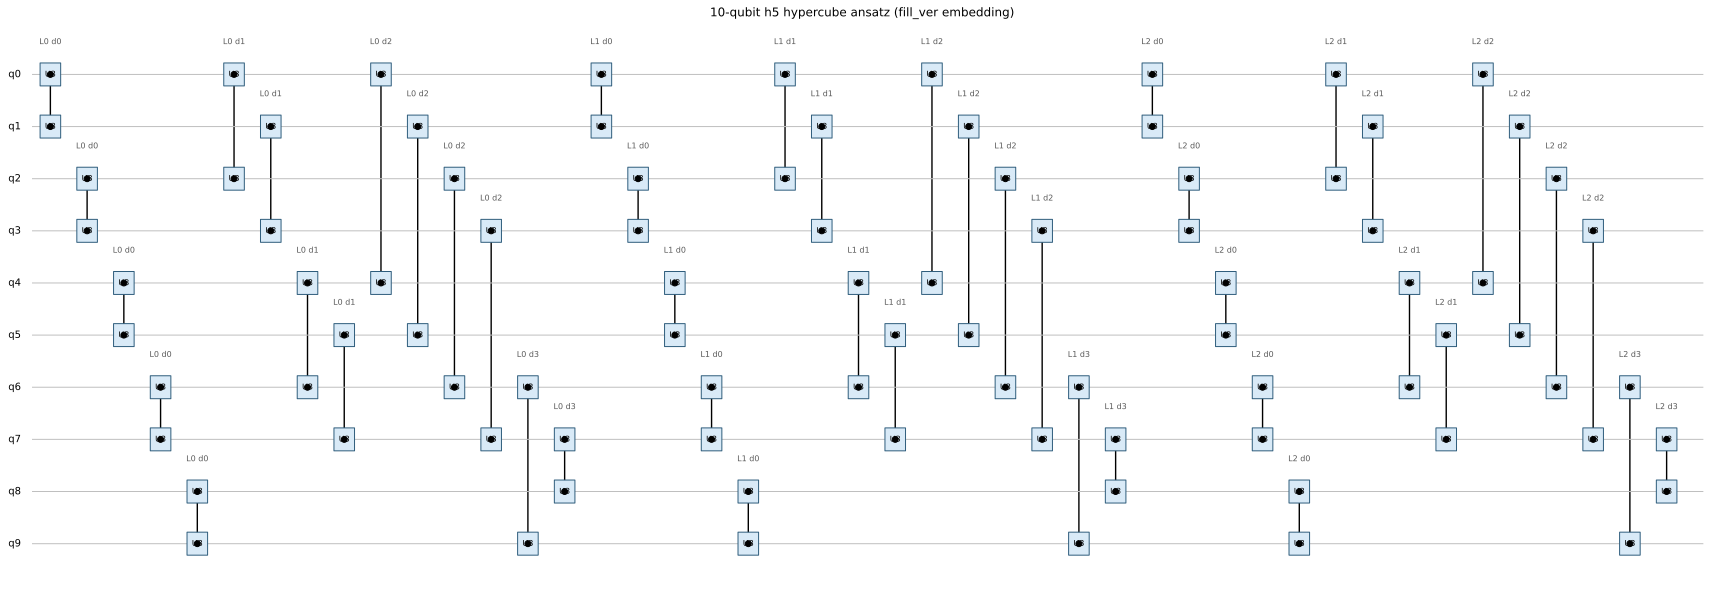

In [10]:
fig, ax = plot_hc_kernel(h5_spec, annotate_params=False)
print('Schedule columns:', len(build_hc_schedule(h5_spec)))
plt.show()


## Optional: Lower One Example to Gemini Move Dialect

The original notebook stopped at the PennyLane/Cirq circuit view. Since this version is already in Gemini physical squin, we can also lower it to the move dialect and inspect the scheduled physical program.


In [ ]:
_ = show_hc_kernel(h5_spec, lower_to_move=True)
